### Environment Setup & Groq Client Configuration

In [10]:
# %% [markdown]
# ### Environment Setup & OpenRouter Client Configuration

# %%
import os
from dotenv import load_dotenv
from openai import OpenAI
from tavily import TavilyClient

load_dotenv()

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

if not OPENROUTER_API_KEY:
    raise ValueError("OPENROUTER_API_KEY is not set in the .env file.")

if not TAVILY_API_KEY:
    raise ValueError("TAVILY_API_KEY is not set in the .env file.")

# Initialize OpenAI Client pointing to OpenRouter
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

tavily_client = TavilyClient(api_key=TAVILY_API_KEY)

MODEL_NAME = "openai/gpt-oss-120b"

print("✅ OpenRouter client initialized successfully.")
print("✅ Tavily client initialized successfully.")
print(f"✅ Model: {MODEL_NAME}")

✅ OpenRouter client initialized successfully.
✅ Tavily client initialized successfully.
✅ Model: openai/gpt-oss-120b


### Tool Implementation & Central Tool Router

In [11]:
# %% [markdown]
# ### Tool Implementation & Central Tool Router

# %%
import os
import sqlite3
from tavily import TavilyClient
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

# ---------------------------------------------------------------------------
# File Paths (Matching your project folder structure)
# ---------------------------------------------------------------------------
CHROMA_DIR = os.path.join("data", "chroma_db")
SQLITE_DB_PATH = os.path.join("data", "company.db")

# ---------------------------------------------------------------------------
# Initialize Persistent Chroma Vector DB Client
# ---------------------------------------------------------------------------
print("⏳ Loading local HuggingFace embeddings ('all-MiniLM-L6-v2')...")
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

if os.path.exists(CHROMA_DIR):
    vectorstore = Chroma(
        persist_directory=CHROMA_DIR,
        embedding_function=embeddings
    )
    print(f"✅ Loaded persistent ChromaDB from '{CHROMA_DIR}'.")
else:
    vectorstore = None
    print(f"⚠️ Warning: '{CHROMA_DIR}' folder not found. Run seed_db.py to generate it.")


# ---------------------------------------------------------------------------
# 1. Real Tavily Web Search
# ---------------------------------------------------------------------------
def execute_tavily_search(query: str, max_results: int = 3) -> str:
    """Performs live web searches via Tavily for external facts, market trends, or pricing."""
    try:
        tavily_api_key = os.getenv("TAVILY_API_KEY")
        if not tavily_api_key:
            return "TOOL_ERROR: TAVILY_API_KEY environment variable is missing."

        tavily_client = TavilyClient(api_key=tavily_api_key)
        response = tavily_client.search(
            query=query, 
            max_results=max_results, 
            search_depth="basic"
        )
        results = response.get("results", [])
        if not results:
            return "NO_EVIDENCE: Tavily returned zero search results."
            
        formatted_results = []
        for res in results:
            formatted_results.append(
                f"- Title: {res.get('title')}\n"
                f"  URL: {res.get('url')}\n"
                f"  Snippet: {res.get('content')}"
            )
        return "\n".join(formatted_results)
    except Exception as e:
        return f"TOOL_ERROR (Tavily): {str(e)}"


# ---------------------------------------------------------------------------
# 2. Local ChromaDB Vector RAG Search
# ---------------------------------------------------------------------------
def query_knowledge_base(query: str, top_k: int = 3) -> str:
    """Searches local ChromaDB vector store for policies, manuals, and support docs."""
    if vectorstore is None:
        return f"TOOL_ERROR: ChromaDB is not initialized. Ensure '{CHROMA_DIR}' exists."
        
    try:
        docs = vectorstore.similarity_search(query, k=top_k)
        if not docs:
            return f"NO_EVIDENCE: No knowledge base entries found matching query '{query}'."

        formatted_docs = []
        for doc in docs:
            formatted_docs.append(f"- {doc.page_content}")

        return f"[Knowledge Base RAG Results for '{query}']:\n" + "\n".join(formatted_docs)

    except Exception as e:
        return f"TOOL_ERROR (ChromaDB): {str(e)}"


# ---------------------------------------------------------------------------
# 3. Local SQLite Database Search (`data/company.db`)
# ---------------------------------------------------------------------------
def query_sales_db(sql_query: str) -> str:
    """Executes read-only SQL SELECT queries against local SQLite database at data/company.db."""
    clean_sql = sql_query.strip().lower()
    if not clean_sql.startswith("select"):
        return "TOOL_ERROR: Security policy violation. Only read-only 'SELECT' queries are allowed."

    if not os.path.exists(SQLITE_DB_PATH):
        return f"TOOL_ERROR: SQLite database file '{SQLITE_DB_PATH}' was not found."

    try:
        with sqlite3.connect(SQLITE_DB_PATH) as conn:
            cursor = conn.cursor()
            cursor.execute(sql_query)
            
            columns = [description[0] for description in cursor.description]
            rows = cursor.fetchall()

            if not rows:
                return f"[SQLite Execution Result]: Query executed successfully, but returned 0 rows."

            results = [dict(zip(columns, row)) for row in rows]
            return f"[SQLite Execution Result]: {results}"

    except Exception as e:
        return f"TOOL_ERROR (SQLite): {str(e)}"


# ---------------------------------------------------------------------------
# 4. Central Tool Router
# ---------------------------------------------------------------------------
def call_tool_by_name(tool_name: str, tool_args: dict) -> str:
    """Router routing function calls requested by Qwen on Groq to Python code."""
    if tool_name == "execute_tavily_search":
        return execute_tavily_search(tool_args["query"])
    elif tool_name == "query_knowledge_base":
        return query_knowledge_base(tool_args["query"])
    elif tool_name == "query_sales_db":
        return query_sales_db(tool_args["sql_query"])
    else:
        return f"TOOL_ERROR: Tool '{tool_name}' is not recognized."

print("✅ Real local tools (ChromaDB & SQLite) successfully initialized.")

⏳ Loading local HuggingFace embeddings ('all-MiniLM-L6-v2')...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Loaded persistent ChromaDB from 'data\chroma_db'.
✅ Real local tools (ChromaDB & SQLite) successfully initialized.


### OpenAI JSON Tool Schemas

In [12]:
# %% [markdown]
# ### JSON Schemas for Tool Calling (OpenAI-Compatible)

# %%
tools_schema = [
    {
        "type": "function",
        "function": {
            "name": "execute_tavily_search",
            "description": "Search the live web using Tavily for market facts, competitor prices, and external news.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string", "description": "Search query."}
                },
                "required": ["query"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "query_knowledge_base",
            "description": "Search internal vector database for company policies, warranties, manuals, and FAQs.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string", "description": "Semantic retrieval query."}
                },
                "required": ["query"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "query_sales_db",
            "description": (
                "Execute read-only SQL SELECT queries on SQLite database (`company.db`).\n\n"
                "DATABASE SCHEMA:\n"
                "- customers(customer_id, name, email, phone, address, created_at)\n"
                "- products(product_id, name, category, price, stock_quantity)\n"
                "- orders(order_id, customer_id, order_date, total_amount, status)\n"
                "- order_items(order_item_id, order_id, product_id, quantity, unit_price)\n\n"
                "USAGE NOTES:\n"
                "- To compute revenue per product, join `order_items` with `products`: `SUM(order_items.quantity * order_items.unit_price)`\n"
                "- Dates in `orders.order_date` are stored in ISO format: 'YYYY-MM-DD HH:MM:SS'\n"
                "- Q1 = 01-01 to 03-31, Q2 = 04-01 to 06-30, Q3 = 07-01 to 09-30, Q4 = 10-01 to 12-31"
            ),
            "parameters": {
                "type": "object",
                "properties": {
                    "sql_query": {"type": "string", "description": "Valid SQL SELECT query string."}
                },
                "required": ["sql_query"],
            },
        },
    }
]

print("✅ Tool Schemas loaded with database schema context.")

✅ Tool Schemas loaded with database schema context.


### LangGraph Architecture Assembly

In [13]:
# %% [markdown]
# ### LangGraph Architecture Assembly with OpenAI-Compatible Calls

# %%
import time
import json
from typing import List, Dict, Any, Sequence, Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

# ---------------------------------------------------------------------------
# State Definition (Stores standard raw OpenAI message dictionaries)
# ---------------------------------------------------------------------------
def add_messages_reducer(left: List[Dict[str, Any]], right: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    return left + right

class AgentState(TypedDict):
    messages: Annotated[List[Dict[str, Any]], add_messages_reducer]

# ---------------------------------------------------------------------------
# System Prompt Definition
# ---------------------------------------------------------------------------
SUPERVISOR_SYSTEM_PROMPT = """You are a Retail Intelligence Supervisor Agent with access to 3 tools:
1. `query_sales_db`: SQLite database for sales numbers, revenue, and product rankings.
2. `query_knowledge_base`: Vector search across company policies, product manuals, shipping FAQs, warranties, and employee handbook.
3. `execute_tavily_search`: Live web search for competitor pricing and external market facts.

OPERATIONAL RULES:
1. Pick tools based on the question. Execute multi-step inquiries sequentially.
2. Base final answers ONLY on evidence retrieved from tool executions and cite sources ([SQL Result], [Knowledge Base], [Web Search]).
3. If tool evidence is insufficient, reply: "I don't know based on available evidence."
"""

# ---------------------------------------------------------------------------
# 1. Agent Node (Invokes Groq via OpenAI client)
# ---------------------------------------------------------------------------
def call_supervisor_agent_node(state: AgentState) -> Dict[str, Any]:
    time.sleep(1.5)  # Throttle to stay under Groq TPM/ITPM
    
    messages = state["messages"]
    
    # Check if context size is getting close to the limit (e.g., > 6 messages)
    if len(messages) > 6:
        system_msg = messages[0]
        user_msg = messages[1]
        
        # Collect intermediate tool results into a condensed text summary
        evidence_summary = []
        for msg in messages[2:-2]:
            if msg.get("role") == "tool":
                # Keep snippet of evidence instead of full payload
                snippet = msg['content'][:300]
                evidence_summary.append(f"[{msg.get('name', 'Tool')[:20]}]: {snippet}")
        
        condensed_history_str = "\n".join(evidence_summary)
        
        # Maintain valid schema: System + User + Compact Memory + Active Unbroken Tool Pair
        compact_messages = [
            system_msg,
            user_msg,
            {
                "role": "user", 
                "content": f"[SUMMARY OF PRIOR RETRIEVED EVIDENCE]:\n{condensed_history_str}"
            }
        ] + messages[-2:]  # Last assistant + last tool response pair remain contiguous
        
        messages = compact_messages

    # Pass the schema-safe compressed messages to Groq
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=messages,
        tools=tools_schema,
        tool_choice="auto"
    )
    
    response_message = response.choices[0].message
    
    assistant_msg = {
        "role": "assistant",
        "content": response_message.content
    }
    
    if response_message.tool_calls:
        assistant_msg["tool_calls"] = [
            {
                "id": tc.id,
                "type": tc.type,
                "function": {
                    "name": tc.function.name,
                    "arguments": tc.function.arguments
                }
            }
            for tc in response_message.tool_calls
        ]
        
    return {"messages": [assistant_msg]}


# ---------------------------------------------------------------------------
# 2. Tool Execution Node
# ---------------------------------------------------------------------------
def execute_tools_node(state: AgentState) -> Dict[str, Any]:
    last_message = state["messages"][-1]
    tool_calls = last_message.get("tool_calls", [])
    tool_responses = []

    for tool_call in tool_calls:
        tool_name = tool_call["function"]["name"]
        tool_args = json.loads(tool_call["function"]["arguments"])
        
        print(f"🔄 Executing Tool: '{tool_name}' | Args: {tool_args}")
        
        tool_output = call_tool_by_name(tool_name, tool_args)
        
        # Append exact OpenAI standard tool message format
        tool_responses.append({
            "tool_call_id": tool_call["id"],
            "role": "tool",
            "name": tool_name,
            "content": str(tool_output)
        })

    return {"messages": tool_responses}


# ---------------------------------------------------------------------------
# 3. Conditional Routing Function
# ---------------------------------------------------------------------------
def route_after_agent(state: AgentState) -> str:
    last_message = state["messages"][-1]
    if "tool_calls" in last_message and last_message["tool_calls"]:
        return "tools"
    return END


# ---------------------------------------------------------------------------
# 4. Graph Construction and Compilation
# ---------------------------------------------------------------------------
workflow = StateGraph(AgentState)

workflow.add_node("agent", call_supervisor_agent_node)
workflow.add_node("tools", execute_tools_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", route_after_agent, {"tools": "tools", END: END})
workflow.add_edge("tools", "agent")

app = workflow.compile()

print("✅ LangGraph Retail Intelligence Agent Graph compiled successfully.")

✅ LangGraph Retail Intelligence Agent Graph compiled successfully.


### Render Mermaid Visual Architecture Graph

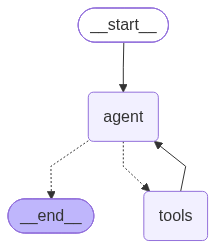

In [14]:
# %% [markdown]
# ### Visualizing the Agent Architecture

# %%
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Mermaid PNG rendering notice:", e)
    print("\nMermaid Code Structure:")
    print(app.get_graph().draw_mermaid())

### Question Entry & Execution Mode

In [15]:
# %% [markdown]
# ### Interactive Entry Cell

# %%
def run_supervisor_agent(user_question: str) -> str:
    """Executes supervisor loop against the compiled LangGraph execution graph."""
    print(f"\n========================================================")
    print(f"QUESTION: {user_question}")
    print(f"========================================================\n")
    
    initial_messages = [
        {"role": "system", "content": SUPERVISOR_SYSTEM_PROMPT},
        {"role": "user", "content": user_question}
    ]
    
    config = {"recursion_limit": 25}
    final_state = app.invoke({"messages": initial_messages}, config=config)
    
    final_answer = final_state["messages"][-1]["content"]
    return final_answer


# Interactive Input Cell
my_question = input("Enter your question: ")

if my_question.strip():
    answer = run_supervisor_agent(my_question)
    print("\n================ FINAL ANSWER ================")
    print(answer)
    print("==============================================\n")


QUESTION: What is our return window for opened laptops?

🔄 Executing Tool: 'query_knowledge_base' | Args: {'query': 'return window for opened laptops'}

================ FINAL ANSWER ================
Our policy states that **opened laptops** (including notebooks, tablets, and handheld gaming devices) have a **14‑calendar‑day return window** from the date of delivery or store pickup. Returns of opened laptops are also subject to a **15 % restocking fee** and must include the original packaging, accessories, and a receipt. [Knowledge Base]

